In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('wine_quality_merged.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [4]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


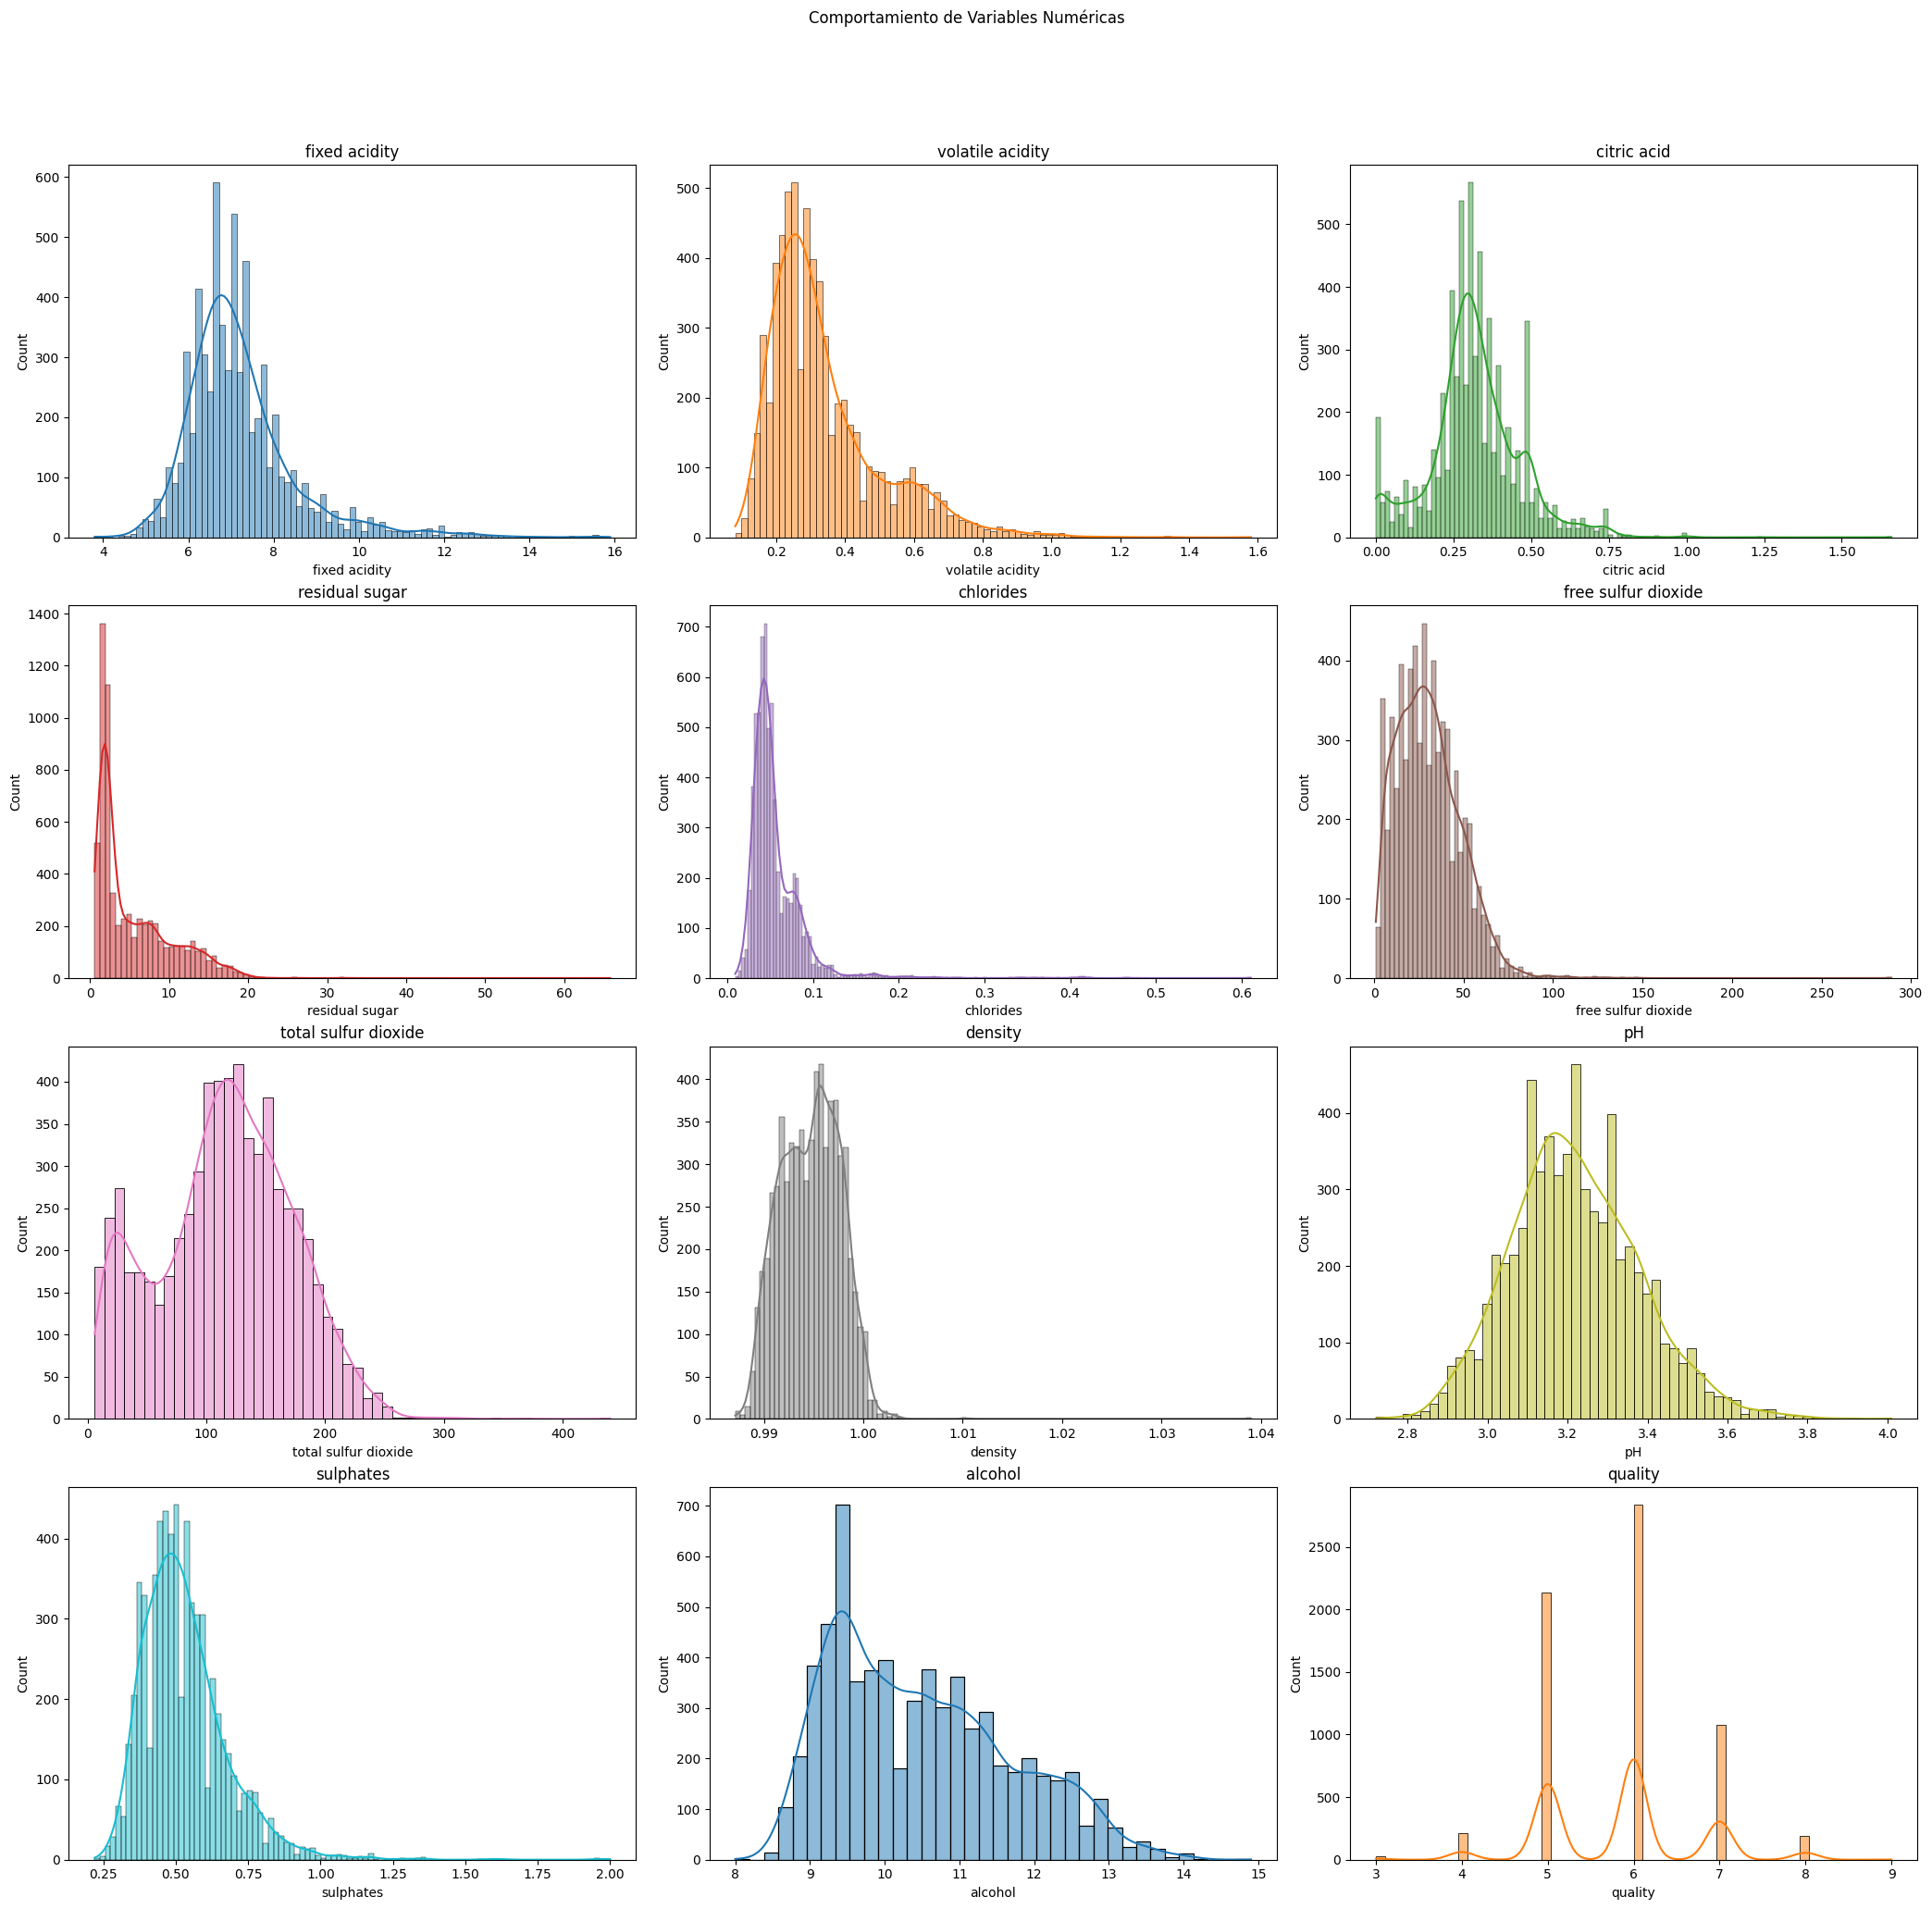

In [5]:
#Gráficos de Histogramas de frecuencia
fig, ax = plt.subplots(4, 3, figsize = (21,21))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sns.histplot(data = data, x = col, kde = True,
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

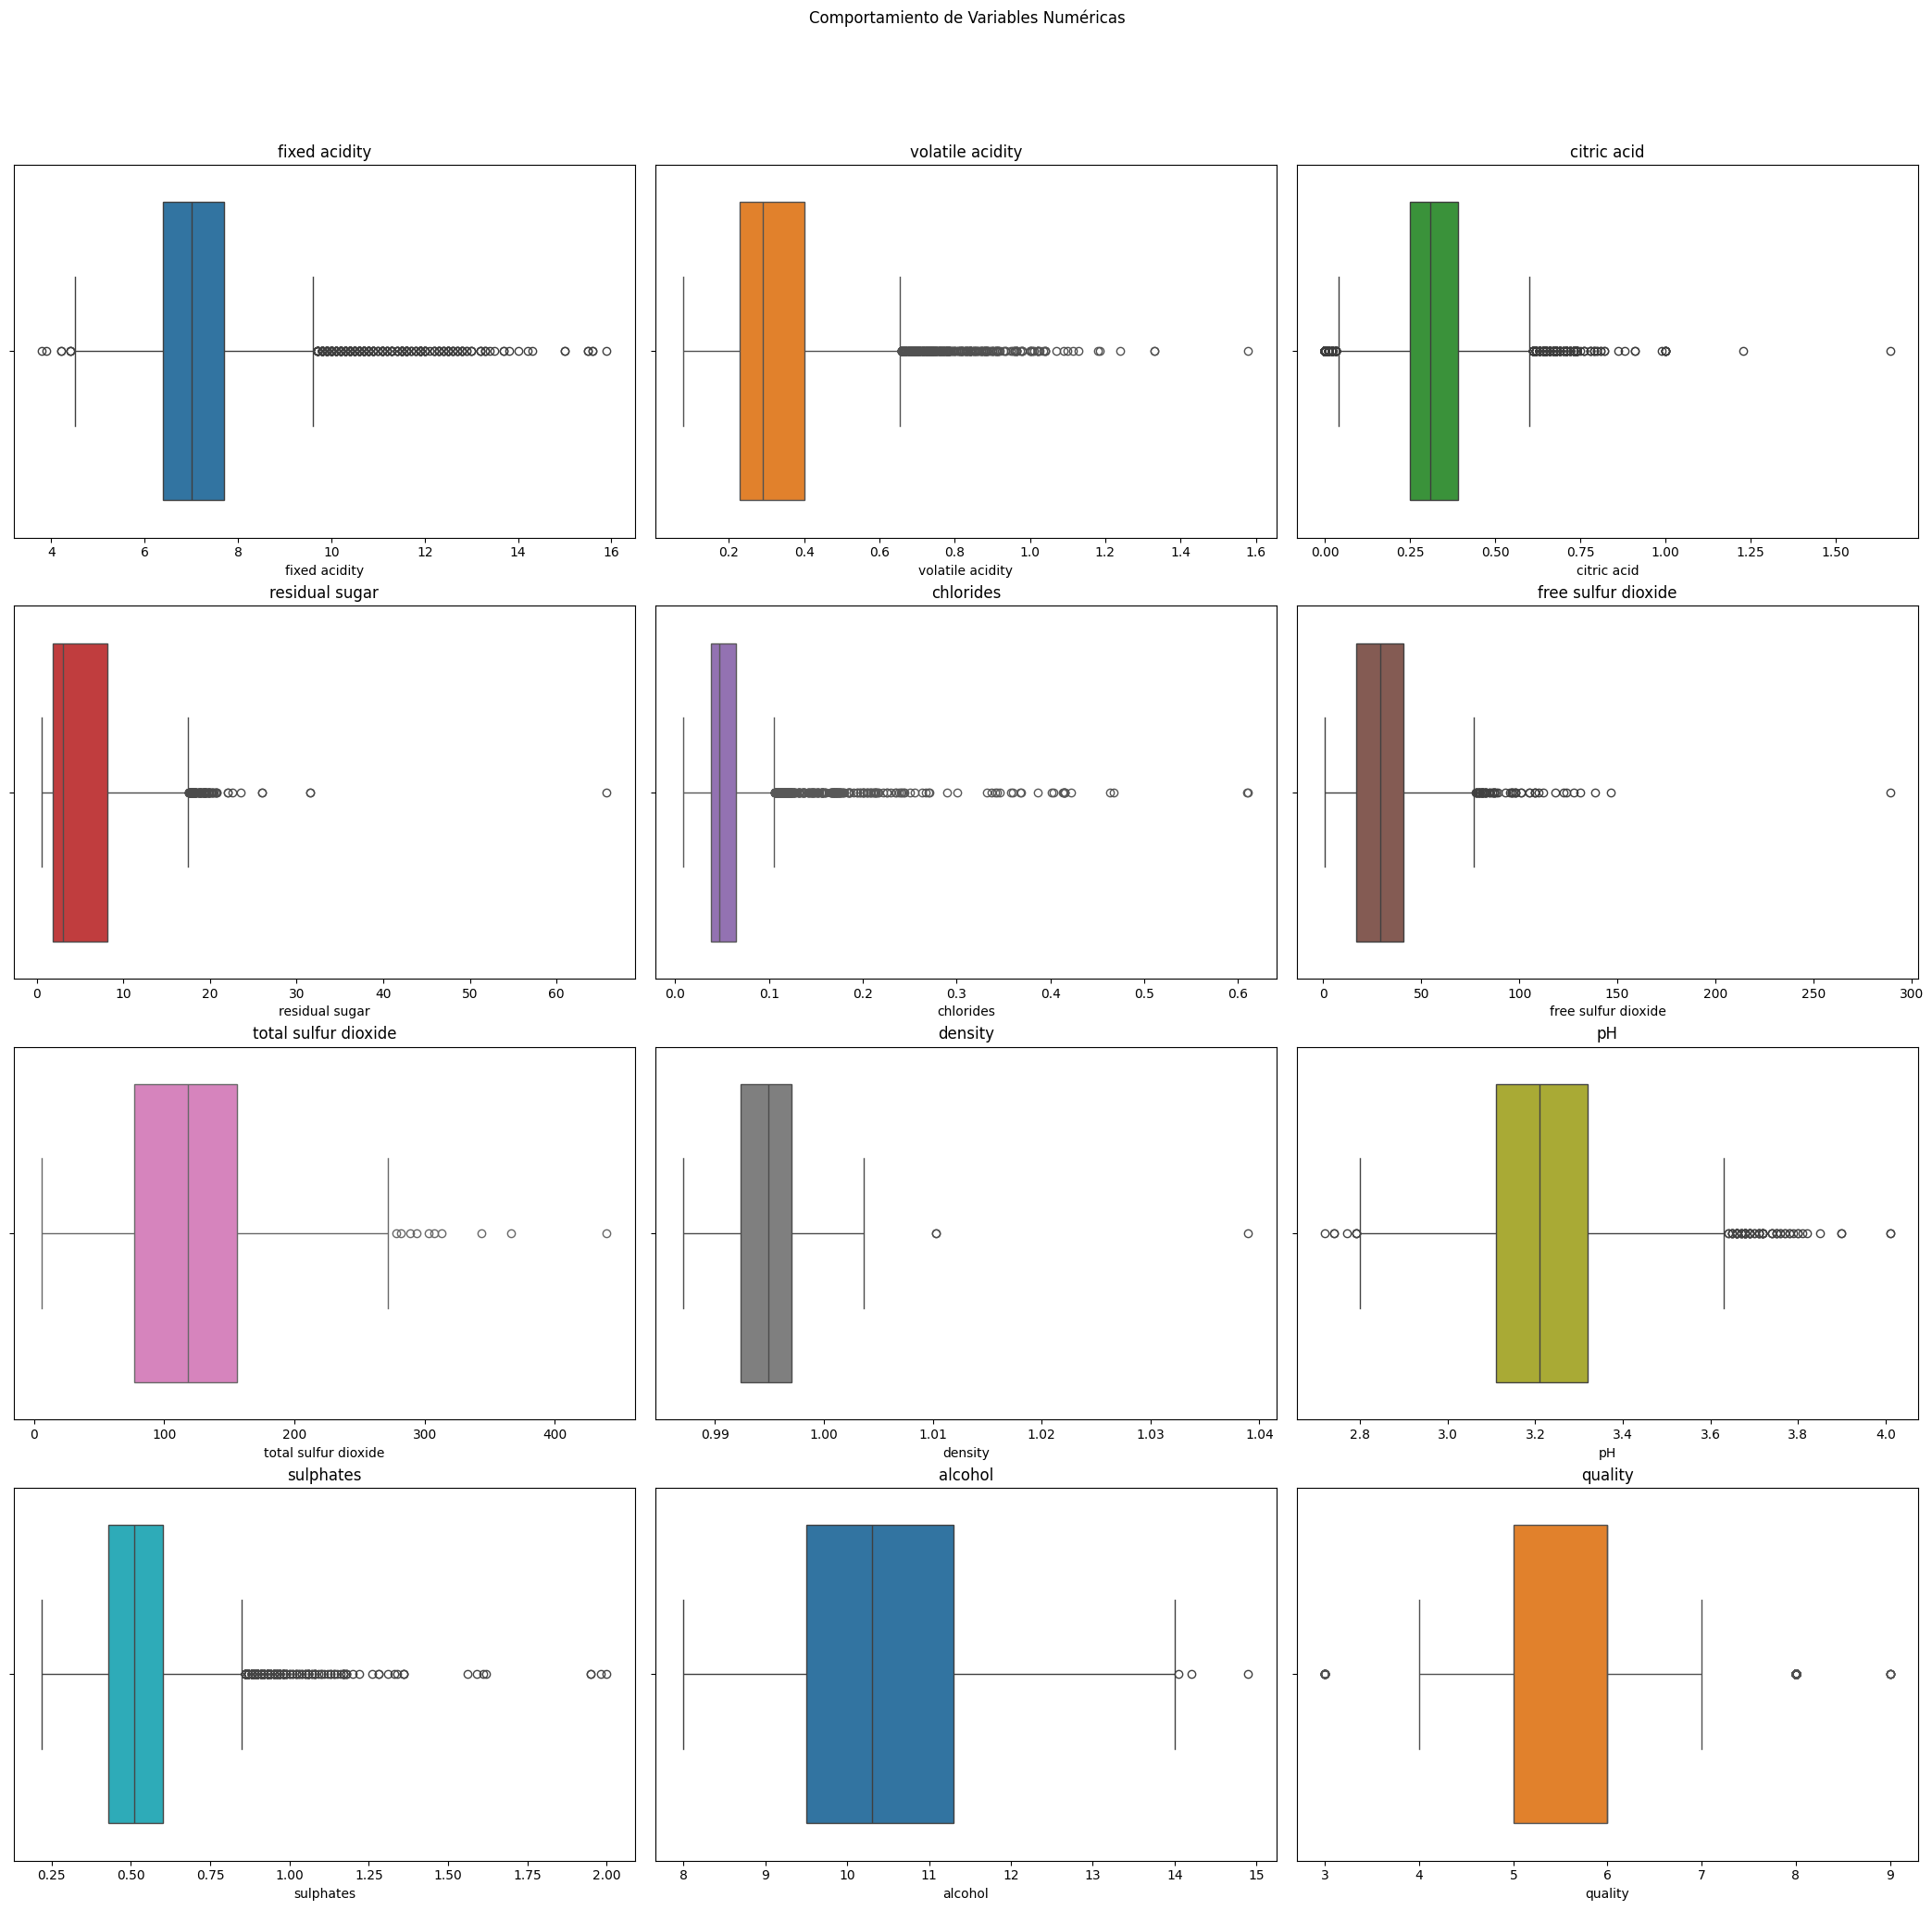

In [6]:
#Gráficos de Histogramas de frecuencia
fig, ax = plt.subplots(4, 3, figsize = (21,21))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sns.boxplot(data = data, x = col,
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

## Entendimiento de los datos:
- `fixed acidity`: No tiene nulos implícitos porque según lo investigado, el valor máximo que tenemos de 15.9 es posible y representa un vino "ácido", que puede corresponder a algunos vinos de clima frio o a los que se les tuvo que añadir ácido para equilibrar el alto contenido en ázucar.  
- `volatile acidity`: También dijimos que no tiene nulos implícitos porque a pesar de que el máximo permitido normalmente está entre 1.2g/L y 1.5g/L, hay algunas excepciones cuando el vino tiene alta azucar residual, donde volatile acidity puede llegar hasta 2.1g/L. Y el valor mínimo de 0.08 también es posible e indica una fermentación muy limpia, entonces también es un atípico natural.
- `citric acid`: Después de investigar, nos encontramos con que por ley, el máximo admisible es de 1g/L, entonces teniendo esto en cuenta y que solo eran dos valores que sobrepasaban el 1g/L, decidimos volverlos nulos explícitos.
- `residual sugar`: Del valor de ázucar residual hubo un único valor extremo que consideramos outlier antinatural, porque bajo el dataset, que se tratan vinos más tipo seco y semiseco, un valor tan alto no tiene sentido.
- `chlorides`: En esta concluimos que los atípicos eran naturales, porque según lo investigado, el límite máximo permitido es generalmente de 1g/L, que en nuestro caso, ningún dato sobrepasa esto.
- `free sulfur dioxide`: Para este vimos que los marcos legales dependían mucho del país, la mayoría rondando por los 70 y algo, pero el más alto que vimos fue de 80ppm, por tanto decidimos asumir como nulos, todos los que exedieran este valor. Y también de lo que vimos, valores muy altos rondando los 100ppm podrían estar hablando de barriles, en vez de vino terminado.
- `total sulfur dioxide`: Para esta variable cogimos el límite máximo legal permitido en Estados Unidos, que es de 350ppm, los dos valores que lo sobrepasaron, los convertimos a nulos.
- `density`: Aunque lo usual es que este entre 0.99g/mL a 0.995g/mL, al inicio de la fermentación pueden alcanzar a valores entre 1.09g/mL a 1.1g/mL y que los vinos dulces pueden tener una densidad más alta por los rangos de 1.05g/mL a 1.07g/mL, lo que hacía a nuestros atípicos posibles.
- `pH`: A pesar de que lo normal, es que el pH oscile entre 2.9 y 4, los outliers que tuvimos se acercaban mucho a estos valores "que son lo normal" y eran posibles.
- `sulphates`: Decidimos convertir a nulos los valores cercanos a 2g/L porque exceden el límite legal.
- `alcohol`: No decidimos eliminar ningún valor de alcohol porque el porcentage máximo es del 15%, mientras que nuestro valor máximo es 14.9%.

In [18]:
data_mod = data.copy()
data_mod.loc[data_mod['citric acid'] > 1, 'citric acid'] = np.nan
data_mod.loc[data_mod['residual sugar'] > 60, 'residual sugar'] = np.nan
data_mod.loc[data_mod['free sulfur dioxide'] > 80, 'free sulfur dioxide'] = np.nan
data_mod.loc[data_mod['total sulfur dioxide'] > 350, 'total sulfur dioxide'] = np.nan
data_mod.loc[data_mod['sulphates'] > 1.75, 'sulphates'] = np.nan
data_mod = data_mod.dropna()
data_mod.info()

<class 'pandas.DataFrame'>
Index: 6439 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6439 non-null   float64
 1   volatile acidity      6439 non-null   float64
 2   citric acid           6439 non-null   float64
 3   residual sugar        6439 non-null   float64
 4   chlorides             6439 non-null   float64
 5   free sulfur dioxide   6439 non-null   float64
 6   total sulfur dioxide  6439 non-null   float64
 7   density               6439 non-null   float64
 8   pH                    6439 non-null   float64
 9   sulphates             6439 non-null   float64
 10  alcohol               6439 non-null   float64
 11  quality               6439 non-null   int64  
 12  type                  6439 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 704.3 KB


In [ ]:
pct_perdido = (6497 - 6439)/6497 * 100
print(f'El porcentaje de datos perdidos es: {pct_perdido:.2f}%, que es menor al 10% permitido, entonces se puede continuar y no hay necesidad de imputar.')

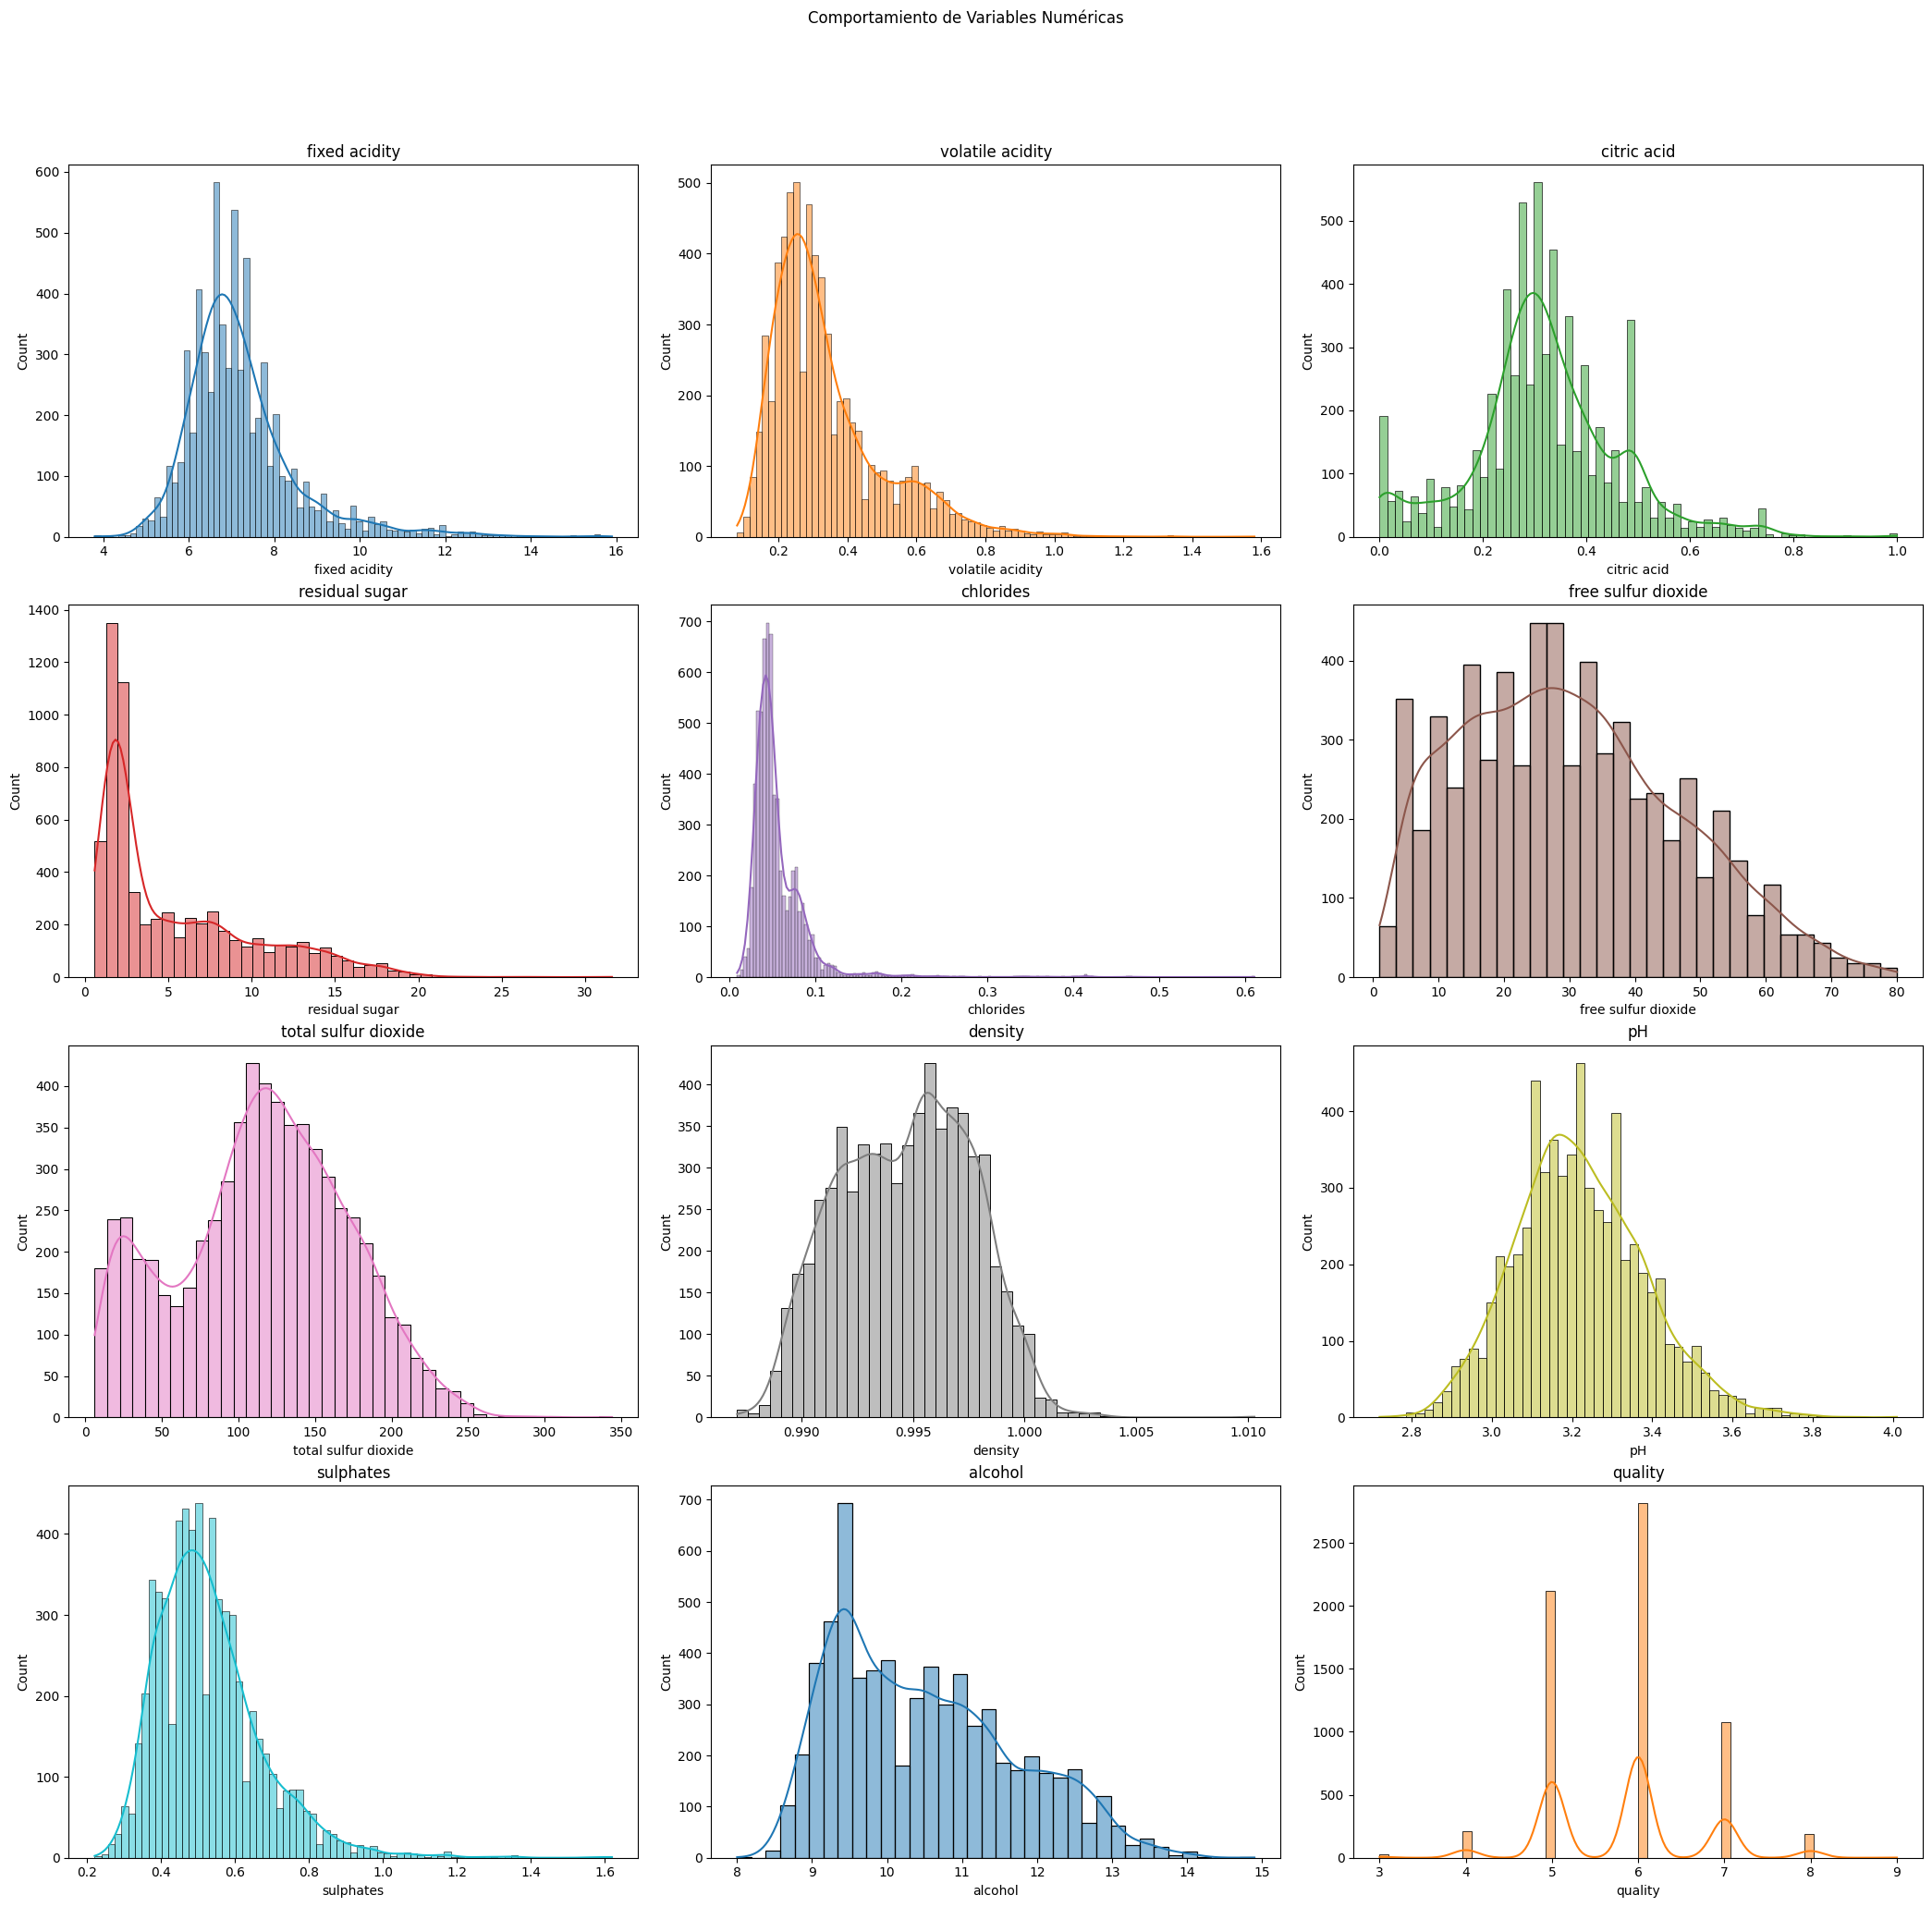

In [ ]:
#Gráficos de Histogramas de frecuencia luego de la eliminación de atípicos
fig, ax = plt.subplots(4, 3, figsize = (21,21))
ax = ax.flat
num_col = data_mod.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sns.histplot(data = data_mod, x = col, kde = True,
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

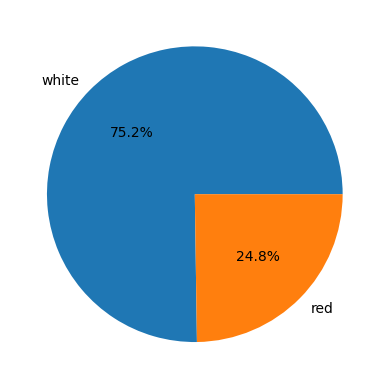

In [23]:
#Gáfico de Torta para la variable objetivo
plt.pie(x = data_mod['type'].value_counts(), labels = data_mod['type'].value_counts().index, autopct = '%0.1f%%')
plt.show()

In [25]:
#BALANCEO
data_red = data_mod[data_mod['type'] == 'red']
data_white = data_mod[data_mod['type'] == 'white']
print(f'El tamaño de la clase red es: {data_red.shape}\n El tamaño de la clase white es: {data_white.shape}')

El tamaño de la clase red es: (1595, 13)
 El tamaño de la clase white es: (4844, 13)


In [26]:
data_red_re = data_red.sample(data_white.shape[0], replace=True)
data_balanced = pd.concat([data_white, data_red_re])
data_balanced.reset_index(drop = True, inplace=True)
data_balanced.info()

<class 'pandas.DataFrame'>
RangeIndex: 9688 entries, 0 to 9687
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         9688 non-null   float64
 1   volatile acidity      9688 non-null   float64
 2   citric acid           9688 non-null   float64
 3   residual sugar        9688 non-null   float64
 4   chlorides             9688 non-null   float64
 5   free sulfur dioxide   9688 non-null   float64
 6   total sulfur dioxide  9688 non-null   float64
 7   density               9688 non-null   float64
 8   pH                    9688 non-null   float64
 9   sulphates             9688 non-null   float64
 10  alcohol               9688 non-null   float64
 11  quality               9688 non-null   int64  
 12  type                  9688 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 984.1 KB


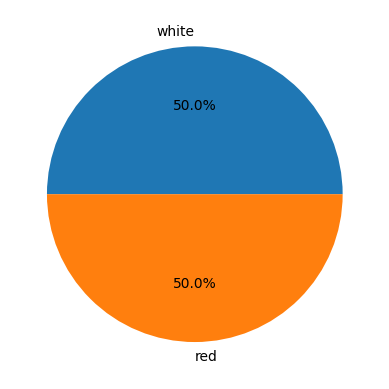

In [28]:
plt.pie(x = data_balanced['type'].value_counts(), labels = data_balanced['type'].value_counts().index, autopct = '%0.1f%%')
plt.show()

In [31]:
data_X = data_balanced.drop(columns='type')
data_y = data_balanced[['type']]

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = data_X.select_dtypes(include= ['int64','float64']).columns.to_list()
num_transformer1 = Pipeline(steps=[('scaler', MinMaxScaler())])
preprocessor1 = ColumnTransformer(transformers=[('num', num_transformer1, num_cols)], remainder='passthrough')
preprocessor1

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fea

In [39]:
data_X_pre1 = preprocessor1.fit_transform(data_X)
data_X_pro1 = pd.DataFrame(data_X_pre1, columns= num_cols)
data_X_pro1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.264463,0.126667,0.36,0.648387,0.059801,0.556962,0.485207,0.598965,0.217054,0.164286,0.115942,0.500000
1,0.206612,0.146667,0.34,0.032258,0.066445,0.164557,0.372781,0.297111,0.449612,0.192857,0.217391,0.500000
2,0.355372,0.133333,0.40,0.203226,0.068106,0.367089,0.269231,0.344545,0.418605,0.157143,0.304348,0.500000
3,0.280992,0.100000,0.32,0.254839,0.081395,0.582278,0.532544,0.366106,0.364341,0.128571,0.275362,0.500000
4,0.280992,0.100000,0.32,0.254839,0.081395,0.582278,0.532544,0.366106,0.364341,0.128571,0.275362,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...
9683,0.454545,0.186667,0.39,0.029032,0.117940,0.506329,0.144970,0.405778,0.581395,0.364286,0.420290,0.500000
9684,0.297521,0.470000,0.19,0.148387,0.141196,0.227848,0.272189,0.432083,0.341085,0.214286,0.227053,0.500000
9685,0.214876,0.366667,0.21,0.032258,0.117940,0.139241,0.076923,0.421734,0.666667,0.314286,0.260870,0.333333
9686,0.198347,0.413333,0.15,0.145161,0.111296,0.151899,0.062130,0.392842,0.635659,0.271429,0.565217,0.500000


In [40]:
num_transformer2 = Pipeline(steps=[('scaler', StandardScaler())])
preprocessor2 = ColumnTransformer(transformers=[('num', num_transformer2, num_cols)], remainder='passthrough')
preprocessor2

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fea

In [41]:
data_X_pre2 = preprocessor2.fit_transform(data_X)
data_X_pro2 = pd.DataFrame(data_X_pre2, columns= num_cols)
data_X_pro2

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.379877,-0.695020,0.347396,3.916647,-0.515581,1.212923,1.321750,2.004495,-1.524674,-0.762955,-1.442131,0.284272
1,-0.831556,-0.537029,0.225047,-0.692044,-0.419149,-0.705398,0.676603,-0.484415,0.313084,-0.512557,-0.839596,0.284272
2,0.329904,-0.642356,0.592094,0.586807,-0.395041,0.284703,0.082388,-0.093301,0.068050,-0.825555,-0.323137,0.284272
3,-0.250826,-0.905676,0.102698,0.972876,-0.202176,1.336685,1.593391,0.084479,-0.360761,-1.075953,-0.495290,0.284272
4,-0.250826,-0.905676,0.102698,0.972876,-0.202176,1.336685,1.593391,0.084479,-0.360761,-1.075953,-0.495290,0.284272
...,...,...,...,...,...,...,...,...,...,...,...,...
9683,1.104212,-0.221046,0.530920,-0.716173,0.328201,0.965397,-0.630670,0.411592,1.354480,0.989833,0.365474,0.284272
9684,-0.121775,2.017165,-0.692570,0.176610,0.665714,-0.395991,0.099366,0.628483,-0.544536,-0.324758,-0.782212,0.284272
9685,-0.767031,1.200877,-0.570221,-0.692044,0.328201,-0.829160,-1.021153,0.543149,2.028325,0.551636,-0.581367,-0.887655
9686,-0.896082,1.569523,-0.937267,0.152480,0.231769,-0.767279,-1.106041,0.304925,1.783291,0.176039,1.226238,0.284272


In [53]:
import sklearn
from sklearn.preprocessing import OrdinalEncoder
categorical_cols = data_y.select_dtypes(include= 'object').columns
categorical_transformer = sklearn.compose.make_column_transformer((OrdinalEncoder(), categorical_cols),
                                                                 remainder = 'passthrough')
categorical_transformer

C:\Users\migue\AppData\Local\Temp\ipykernel_28500\411377590.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data_y.select_dtypes(include= 'object').columns


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinalencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.

In [56]:
data_transformed = pd.DataFrame(categorical_transformer.fit_transform(data_y),
                                columns=categorical_transformer.get_feature_names_out(),
                                index=data_y.index).rename(columns= lambda x: x.removeprefix('ordinalencoder__')).rename(columns= lambda x: x.removeprefix('remainder__'))
data_transformed

,type
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
9683,0.0
9684,0.0
9685,0.0
9686,0.0


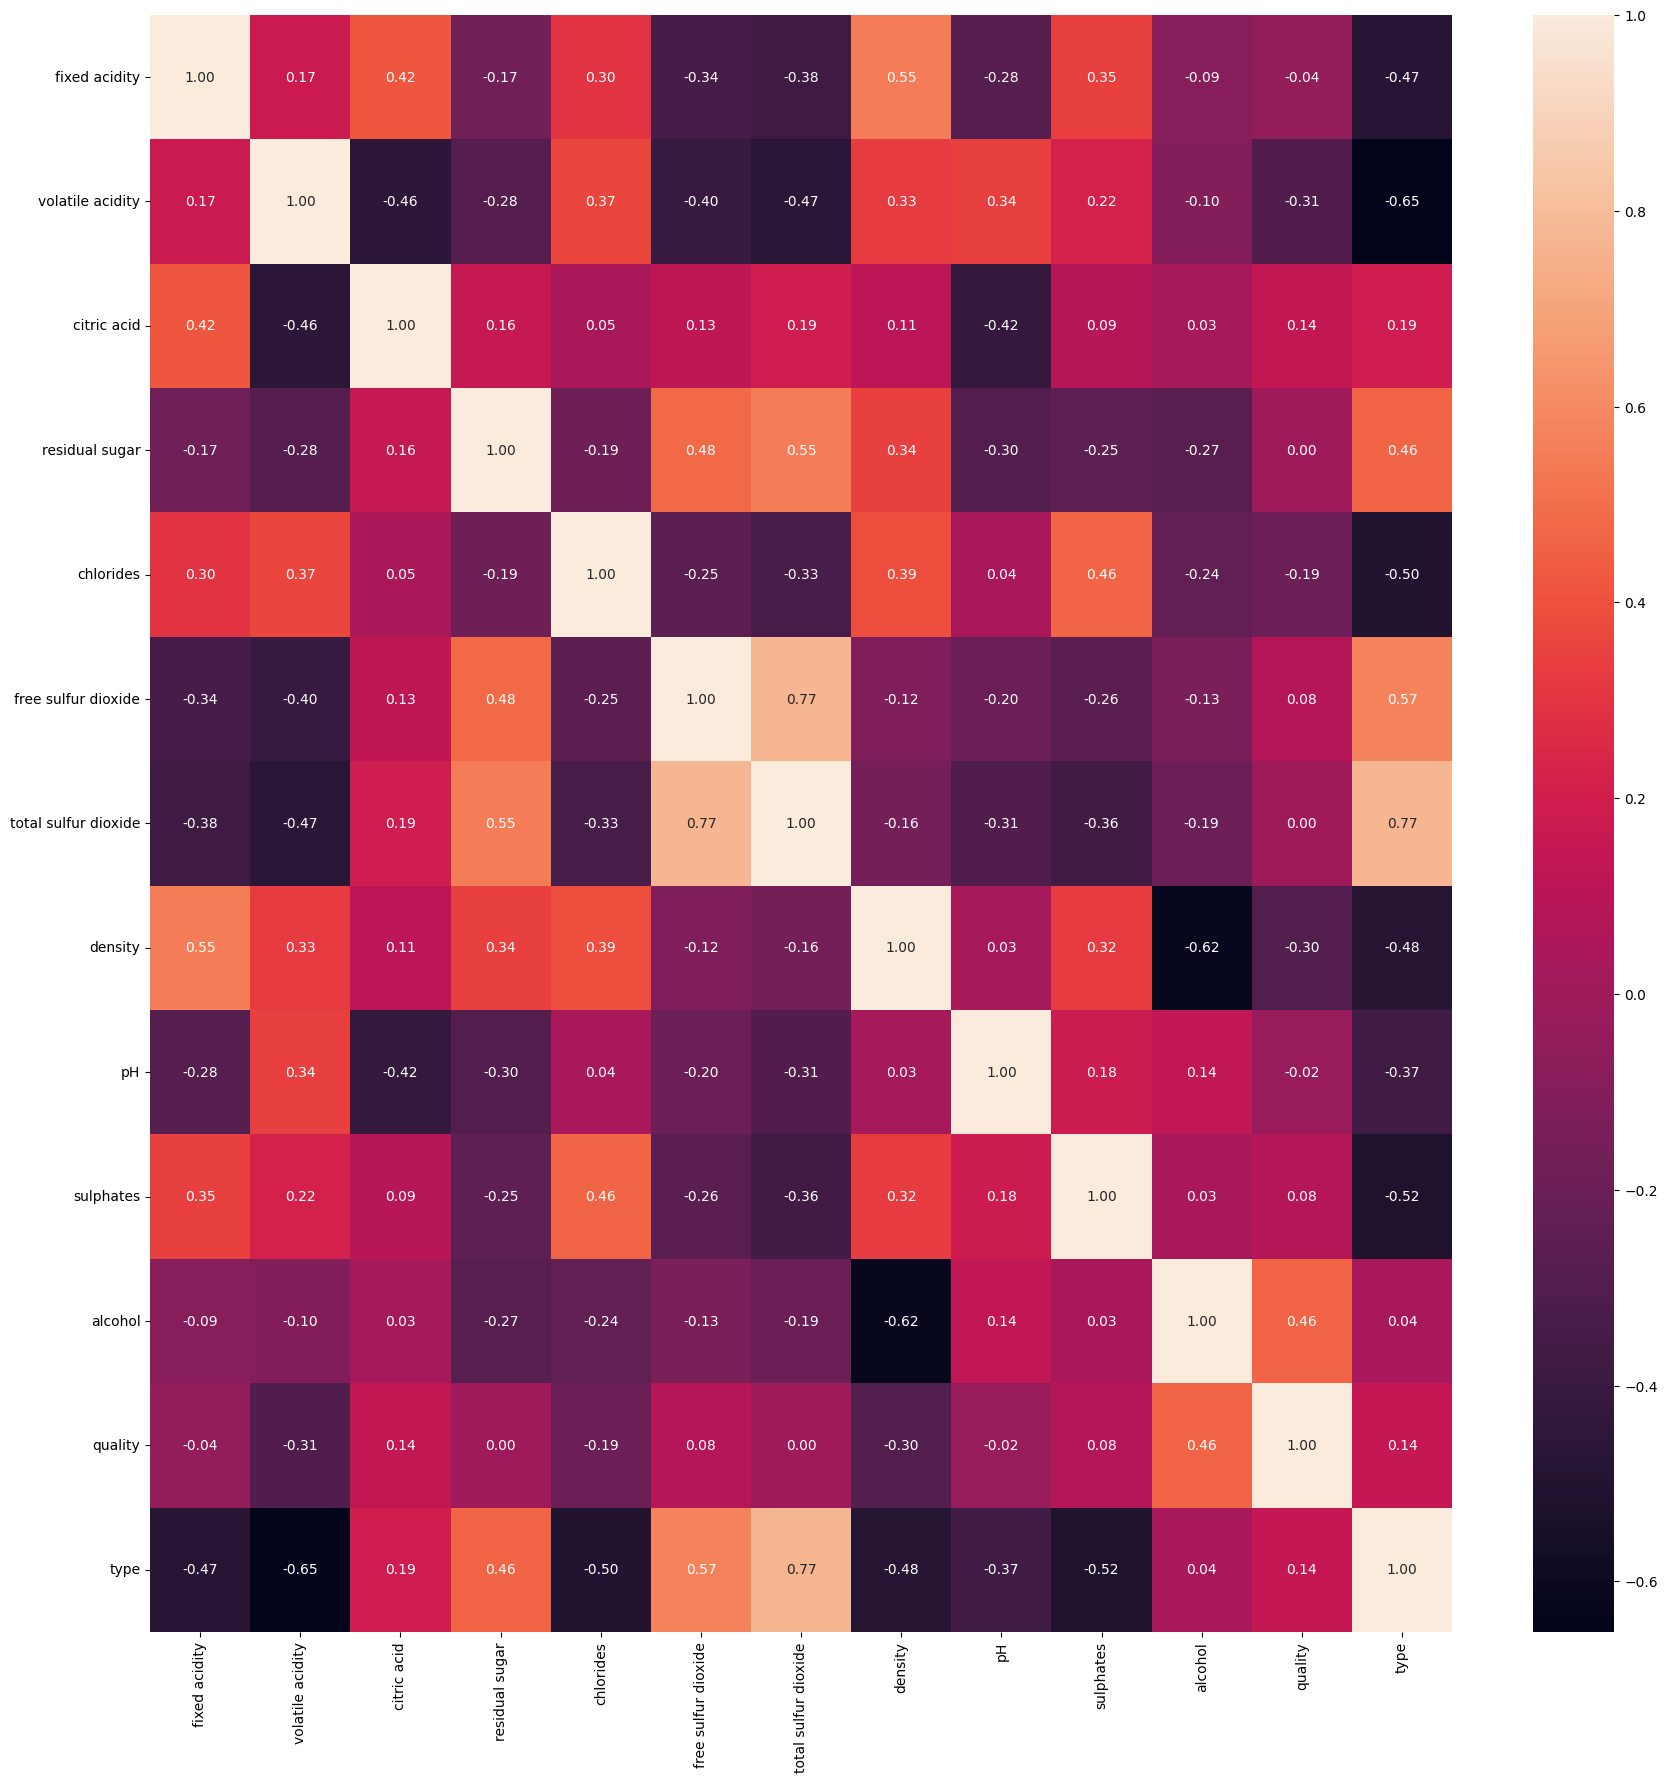

In [58]:
prueba = pd.concat([data_X_pro2, data_transformed], axis=1)

plt.figure(figsize= (21,21))
sns.heatmap(data=prueba.corr(numeric_only= True), annot= True, fmt= '0.2f')
plt.show()

## Prueba con modelo base para seleccionar estandarizacion o normalizacion

In [48]:
from sklearn.model_selection import train_test_split
X_trainN, X_testN, y_trainN, y_testN = train_test_split(data_X_pro1, data_y, train_size=0.7, random_state=32)
X_trainE, X_testE, y_trainE, y_testE = train_test_split(data_X_pro2, data_y, train_size=0.7, random_state=32)
print(f'El tamaño del conjunto de entrenamiento normalizado es: {X_trainN.shape} {y_trainN.shape}\ny el tamaño del conjunto de validacion normalizado es {X_testN.shape, y_testN.shape}')
print(f'El tamaño del conjunto de entrenamiento estandarizado es: {X_trainE.shape} {y_trainE.shape}\ny el tamaño del conjunto de validacion estandarizado es {X_testE.shape, y_testE.shape}')

El tamaño del conjunto de entrenamiento normalizado es: (6781, 12) (6781, 1)
y el tamaño del conjunto de validacion normalizado es ((2907, 12), (2907, 1))
El tamaño del conjunto de entrenamiento estandarizado es: (6781, 12) (6781, 1)
y el tamaño del conjunto de validacion estandarizado es ((2907, 12), (2907, 1))


In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
modelN1 = DecisionTreeClassifier(random_state=32)
modelN2 = KNeighborsClassifier()
modelE1 = DecisionTreeClassifier(random_state=32)
modelE2 = KNeighborsClassifier()
modelN1.fit(X_trainN, y_trainN)
modelN2.fit(X_trainN, y_trainN)
modelE1.fit(X_trainE, y_trainE)
modelE2.fit(X_trainE, y_trainE)
pred1N = modelN1.predict(X_testN)
pred2N = modelN2.predict(X_testN)
pred1E = modelE1.predict(X_testE)
pred2E = modelE2.predict(X_testE)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [50]:
from sklearn.metrics import classification_report
print(classification_report(y_testN, pred1N))
print(classification_report(y_testE, pred1E))

              precision    recall  f1-score   support

         red       0.99      1.00      0.99      1513
       white       1.00      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907

              precision    recall  f1-score   support

         red       0.99      1.00      0.99      1513
       white       1.00      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907



In [51]:
print(classification_report(y_testN, pred2N))
print(classification_report(y_testE, pred2E))

              precision    recall  f1-score   support

         red       0.99      0.99      0.99      1513
       white       0.99      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907

              precision    recall  f1-score   support

         red       0.99      0.99      0.99      1513
       white       0.99      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907



In [52]:
print("Train scores:")
print(f"DecisionTree Norm: {modelN1.score(X_trainN, y_trainN):.4f}")
print(f"DecisionTree Est:  {modelE1.score(X_trainE, y_trainE):.4f}")

print("\nTest scores:")
print(f"DecisionTree Norm: {modelN1.score(X_testN, y_testN):.4f}")
print(f"DecisionTree Est:  {modelE1.score(X_testE, y_testE):.4f}")

Train scores:
DecisionTree Norm: 0.9997
DecisionTree Est:  0.9997

Test scores:
DecisionTree Norm: 0.9942
DecisionTree Est:  0.9942


Se decidió usar el MinMaxScaler()